# Calibrazione: 30 frame - Cattura 15 frame per classificare la postura

In [ ]:
import urllib.request
import pandas as pd

df = pd.read_csv("data.csv")
print(f"Dataset caricato! Shape: {df.shape}")

In [ ]:
!pip install opencv-python mediapipe

# **1. Dataset**

## Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Dataset Loading

In [ ]:
DATA_PATH = "data.csv"
df = pd.read_csv(DATA_PATH)

## Landmark Selection

In [ ]:
selected_columns = [
    "subject",
    "upperbody_label",
    "nose_x", "nose_y", "nose_z",
    "left_eye_x", "left_eye_y", "left_eye_z",
    "right_eye_x", "right_eye_y", "right_eye_z",
    "left_ear_x", "left_ear_y", "left_ear_z",
    "right_ear_x", "right_ear_y", "right_ear_z",
    "left_shoulder_x", "left_shoulder_y", "left_shoulder_z",
    "right_shoulder_x", "right_shoulder_y", "right_shoulder_z",
    "left_hip_x", "left_hip_y", "left_hip_z",
    "right_hip_x", "right_hip_y", "right_hip_z"
]

missing_cols = [col for col in selected_columns if col not in df.columns]
if missing_cols:
    raise ValueError(f"Missing columns in dataset: {missing_cols}")

df_posture = df[selected_columns].copy()

print("Selected dataset shape:", df_posture.shape)
print("Total missing values:", df_posture.isnull().sum().sum())

## Midpoint Construction

In [ ]:
# Thresholds for future consistency with the real-time pipeline
HEAD_Z_CONF_THR = 0.6
SHOULDER_CONF_THR = 0.6
HIP_CONF_THR = 0.6


# Compute the midpoint between two bilateral landmarks
def add_midpoint(df, left_prefix, right_prefix, out_prefix):
    # Check whether all coordinates are available for the left landmark
    left_available = df[
        [f"{left_prefix}_{axis}" for axis in ["x", "y", "z"]]
    ].notna().all(axis=1)

    # Check whether all coordinates are available for the right landmark
    right_available = df[
        [f"{right_prefix}_{axis}" for axis in ["x", "y", "z"]]
    ].notna().all(axis=1)

    # The midpoint is available only when both landmarks are present
    available = left_available & right_available

    # Compute midpoint coordinates for each axis
    for axis in ["x", "y", "z"]:
        midpoint = (df[f"{left_prefix}_{axis}"] + df[f"{right_prefix}_{axis}"]) / 2
        df[f"{out_prefix}_{axis}"] = np.where(available, midpoint, np.nan)

    # Store binary availability information
    df[f"{out_prefix}_available"] = available

    # Store binary confidence information
    # The offline dataset does not provide continuous visibility scores
    df[f"{out_prefix}_conf"] = available.astype(float)

    return df


# Compute bilateral midpoints used for posture representation
df_posture = add_midpoint(df_posture, "left_shoulder", "right_shoulder", "mid_shoulder")
df_posture = add_midpoint(df_posture, "left_hip", "right_hip", "mid_hip")
df_posture = add_midpoint(df_posture, "left_ear", "right_ear", "mid_ear")
df_posture = add_midpoint(df_posture, "left_eye", "right_eye", "mid_eye")


# Define reliability flags for the main structural midpoints
df_posture["mid_shoulder_reliable"] = df_posture["mid_shoulder_available"]
df_posture["mid_hip_reliable"] = df_posture["mid_hip_available"]


# Check availability of candidate landmarks for head center construction
eye_available = df_posture[
    [
        "left_eye_x", "left_eye_y", "left_eye_z",
        "right_eye_x", "right_eye_y", "right_eye_z"
    ]
].notna().all(axis=1)

ear_available = df_posture[
    [
        "left_ear_x", "left_ear_y", "left_ear_z",
        "right_ear_x", "right_ear_y", "right_ear_z"
    ]
].notna().all(axis=1)

nose_available = df_posture[
    ["nose_x", "nose_y", "nose_z"]
].notna().all(axis=1)


# Construct head center coordinates using a hierarchical fallback strategy
# Priority: mid-eye -> mid-ear -> nose
for axis in ["x", "y", "z"]:
    df_posture[f"head_center_{axis}"] = np.where(
        eye_available,
        df_posture[f"mid_eye_{axis}"],
        np.where(
            ear_available,
            df_posture[f"mid_ear_{axis}"],
            np.where(
                nose_available,
                df_posture[f"nose_{axis}"],
                np.nan
            )
        )
    )


# Track which landmark source was used for head center construction
df_posture["head_center_source"] = np.where(
    eye_available,
    "mid_eye",
    np.where(
        ear_available,
        "mid_ear",
        np.where(nose_available, "nose", "missing")
    )
)


# Store availability and binary confidence for head center
df_posture["head_center_available"] = (
    eye_available |
    ear_available |
    nose_available
)

# The offline dataset uses binary confidence only
df_posture["head_center_conf"] = df_posture["head_center_available"].astype(float)


# Define z-axis reliability flags
# Depth is considered more reliable when head center comes from bilateral landmarks
df_posture["head_center_z_reliable"] = df_posture["head_center_source"].isin(
    ["mid_eye", "mid_ear"]
)

# Upper-body depth is reliable only if both head center and shoulder midpoint are reliable
df_posture["upper_z_reliable"] = (
    df_posture["head_center_z_reliable"] &
    df_posture["mid_shoulder_reliable"]
)


# Quick inspection of the generated midpoint and reliability features
print(
    df_posture[
        [
            "mid_shoulder_x", "mid_shoulder_y", "mid_shoulder_z",
            "mid_shoulder_available", "mid_shoulder_conf", "mid_shoulder_reliable",

            "mid_hip_x", "mid_hip_y", "mid_hip_z",
            "mid_hip_available", "mid_hip_conf", "mid_hip_reliable",

            "mid_ear_x", "mid_ear_y", "mid_ear_z",
            "mid_ear_available", "mid_ear_conf",

            "mid_eye_x", "mid_eye_y", "mid_eye_z",
            "mid_eye_available", "mid_eye_conf",

            "head_center_x", "head_center_y", "head_center_z",
            "head_center_source", "head_center_available", "head_center_conf",

            "head_center_z_reliable",
            "upper_z_reliable"
        ]
    ].head()
)

## Feature Definition

### Primary Features

In [ ]:
eps = 1e-6

# Wrap angle to [-90, 90)
def wrap_angle_90(angle_deg):
    return ((angle_deg + 90) % 180) - 90


# Signed angular difference in [-180, 180)
def angle_diff_deg(a, b):
    return (a - b + 180) % 360 - 180


# Required columns check
required_columns = [
    "left_shoulder_x", "left_shoulder_y",
    "right_shoulder_x", "right_shoulder_y",
    "left_eye_x", "left_eye_y", "right_eye_x", "right_eye_y",
    "left_ear_x", "left_ear_y", "right_ear_x", "right_ear_y",
    "head_center_x", "head_center_y", "head_center_z",
    "mid_shoulder_x", "mid_shoulder_y", "mid_shoulder_z",
    "upper_z_reliable"
]

missing_columns = [col for col in required_columns if col not in df_posture.columns]
if missing_columns:
    raise KeyError(f"Missing required columns: {missing_columns}")


# =========================
# 1) SHOULDERS GEOMETRY
# =========================
dx_shoulder = df_posture["right_shoulder_x"] - df_posture["left_shoulder_x"]
dy_shoulder = df_posture["right_shoulder_y"] - df_posture["left_shoulder_y"]

df_posture["shoulder_slope"] = wrap_angle_90(
    np.degrees(np.arctan2(dy_shoulder, dx_shoulder))
)

df_posture["shoulder_width"] = np.hypot(dx_shoulder, dy_shoulder)
df_posture["shoulder_width"] = df_posture["shoulder_width"].replace(0, np.nan)
df_posture["shoulder_width_safe"] = df_posture["shoulder_width"].fillna(eps)

u_x = dx_shoulder / df_posture["shoulder_width_safe"]
u_y = dy_shoulder / df_posture["shoulder_width_safe"]

n_x = -u_y
n_y = u_x

flip_mask = n_y > 0
n_x = np.where(flip_mask, -n_x, n_x)
n_y = np.where(flip_mask, -n_y, n_y)


# =========================
# 2) HEAD ORIENTATION
# =========================
eye_available = df_posture[
    ["left_eye_x", "left_eye_y", "right_eye_x", "right_eye_y"]
].notna().all(axis=1)

ear_available = df_posture[
    ["left_ear_x", "left_ear_y", "right_ear_x", "right_ear_y"]
].notna().all(axis=1)

dx_eye = df_posture["right_eye_x"] - df_posture["left_eye_x"]
dy_eye = df_posture["right_eye_y"] - df_posture["left_eye_y"]
head_tilt_eye = wrap_angle_90(np.degrees(np.arctan2(dy_eye, dx_eye)))

dx_ear = df_posture["right_ear_x"] - df_posture["left_ear_x"]
dy_ear = df_posture["right_ear_y"] - df_posture["left_ear_y"]
head_tilt_ear = wrap_angle_90(np.degrees(np.arctan2(dy_ear, dx_ear)))

df_posture["head_tilt"] = np.where(
    eye_available,
    head_tilt_eye,
    np.where(ear_available, head_tilt_ear, np.nan)
)


# =========================
# 3) HEAD RELATIVE TO SHOULDERS
# =========================
H_x = df_posture["head_center_x"] - df_posture["mid_shoulder_x"]
H_y = df_posture["head_center_y"] - df_posture["mid_shoulder_y"]
H_z = df_posture["head_center_z"] - df_posture["mid_shoulder_z"]

proj_shoulder_axis   = H_x * u_x + H_y * u_y
proj_shoulder_normal = H_x * n_x + H_y * n_y

df_posture["head_lateral_ratio"] = proj_shoulder_axis / df_posture["shoulder_width_safe"]
df_posture["head_y_ratio"]       = proj_shoulder_normal / df_posture["shoulder_width_safe"]


# =========================
# 4) 2D POSTURAL ANGLES
# =========================
df_posture["upper_body_inclination"] = wrap_angle_90(
    np.degrees(np.arctan2(proj_shoulder_axis, proj_shoulder_normal + eps))
)

norm_H_2d = np.sqrt(H_x**2 + H_y**2) + eps
cos_theta = (-H_y) / norm_H_2d
cos_theta = np.clip(cos_theta, -1.0, 1.0)

df_posture["head_neck_vertical_angle"] = np.degrees(np.arccos(cos_theta))


# =========================
# 5) RELATIVE ANGULAR FEATURES
# =========================
df_posture["head_shoulder_alignment"] = angle_diff_deg(
    df_posture["head_tilt"],
    df_posture["shoulder_slope"]
)

df_posture["head_trunk_diff"] = angle_diff_deg(
    df_posture["head_tilt"],
    df_posture["upper_body_inclination"]
)

# shoulder_trunk_diff RIMOSSA — correlazione 0.92 con head_trunk_diff (ridondante)


# =========================
# 6) DIAGNOSTIC (non entra nel modello)
# =========================
df_posture["head_depth_ratio_diag"] = np.where(
    df_posture["upper_z_reliable"],
    H_z / df_posture["shoulder_width_safe"],
    np.nan
)


# =========================
# 7) FINAL PRIMARY FEATURE LIST — 8 feature
# =========================
primary_features = [
    "head_tilt",
    "shoulder_slope",
    "head_lateral_ratio",
    "head_y_ratio",
    "head_neck_vertical_angle",
    "head_shoulder_alignment",
    "upper_body_inclination",
    "head_trunk_diff",
]

missing_primary_features = [col for col in primary_features if col not in df_posture.columns]
if missing_primary_features:
    raise KeyError(f"Missing primary features: {missing_primary_features}")

print("PRIMARY FEATURES:")
print(primary_features)

### Support Features

The support features extend the postural representation by incorporating additional information derived from the pelvis, whenever these landmarks are available and sufficiently reliable. These features do not constitute the core of the dataset; rather, they provide an additional level of postural description that is particularly useful for modeling trunk alignment.

More specifically, this group includes measures describing the geometry of the segment between the hips and the shoulders, such as trunk lateral inclination, forward/backward trunk inclination, and its depth-related component. In addition, an anatomical feature is introduced to approximate the relationship between the neck/head direction and the trunk direction.

Since these measures depend on the correct observation of the hip landmarks, they are computed only when the required anatomical references are available. In this way, the support features maintain a complementary role: they enrich the dataset when reliable information is present, without compromising the overall robustness of the pipeline.

In [ ]:
# =========================
# SUPPORT FEATURES — solo trunk_forward_backward_angle (fix T_y)
# =========================
#
# Fix geometrico: in coordinate immagine MediaPipe, y cresce verso il basso.
# T_y = mid_shoulder_y - mid_hip_y è negativo (spalle sopra le anche).
# arctan2(T_z, T_y_negativo) produceva angoli ~±180° invece di ~0°.
# Fix: usare -T_y per riportare nel sistema biomeccanico (y verso l'alto).
#
# Feature rimosse definitivamente (bug non recuperabile con questa geometria):
#   - neck_trunk_angle_anatomical  (dot product invertito per stesso motivo)
#   - trunk_lateral_angle          (arctan2(T_x, T_y) stesso bug su piano xy)
#   - trunk_depth                  (z MediaPipe troppo rumorosa a 30/45°)
#   - shoulder_trunk_diff          (ridondante, corr=0.92 con head_trunk_diff)
#
# Feature mantenuta con fix:
#   - trunk_forward_backward_angle (arctan2(T_z, -T_y) — segnale sagittale)

# =========================
# VETTORI
# =========================
T_x = df_posture["mid_shoulder_x"] - df_posture["mid_hip_x"]
T_y = df_posture["mid_shoulder_y"] - df_posture["mid_hip_y"]
T_z = df_posture["mid_shoulder_z"] - df_posture["mid_hip_z"]

# =========================
# RELIABILITY FLAG
# =========================
df_posture["trunk_support_reliable"] = (
    df_posture["mid_shoulder_reliable"] &
    df_posture["mid_hip_reliable"]
)

# =========================
# trunk_forward_backward_angle — FIX: -T_y
# =========================
# arctan2(T_z, -T_y):
#   T_z > 0 → testa più vicina alla camera delle anche → forward lean → angolo positivo
#   T_z < 0 → testa più lontana → backward lean → angolo negativo
#   -T_y > 0 sempre (spalle sopra anche) → angolo ~0° in postura neutra

trunk_fba_raw = np.degrees(
    np.arctan2(T_z, -T_y + 1e-6)
)

df_posture["trunk_forward_backward_angle"] = np.where(
    df_posture["trunk_support_reliable"],
    trunk_fba_raw,
    np.nan
)

# =========================
# FINAL SUPPORT FEATURE LIST — 1 feature
# =========================
support_features = ["trunk_forward_backward_angle"]

missing_support = [col for col in support_features if col not in df_posture.columns]
if missing_support:
    raise KeyError(f"Missing support features: {missing_support}")

print("SUPPORT FEATURES (fixate):")
print(support_features)

print("\nQuick check trunk_forward_backward_angle:")
print(df_posture["trunk_forward_backward_angle"].describe().round(3))
print(f"\nValori NaN: {df_posture['trunk_forward_backward_angle'].isna().sum()}")
print(f"Valori fuori [-30, 30]: {((df_posture['trunk_forward_backward_angle'].abs() > 30) & df_posture['trunk_forward_backward_angle'].notna()).sum()}")

## Final Dataset Construction

At this stage, the final dataset containing the features derived from the selected and transformed landmarks is assembled.

The features used by the model are obtained by combining the **primary features**, based on head and shoulder information, with the **support features**, derived from trunk-related geometry when the required landmarks are available. This integration makes it possible to preserve a balance between robustness and completeness in the postural representation.

During the previous stages, several intermediate variables are also generated, including vector components, normalized quantities, and diagnostic features. These variables are retained in the working DataFrame to ensure traceability and to facilitate debugging. However, they are not included in the final model dataset, in order to avoid redundancy and to preserve a compact and interpretable feature representation.

Two distinct datasets are generated:

- **Model dataset**: contains only the features used as model input, together with the subject identifier and the postural class label. This dataset represents the main output of the feature engineering pipeline.

- **Debug dataset**: includes, in addition to the model features, diagnostic variables and reliability flags. This version is intended to support transformation verification, feature inspection, and possible downstream error analysis.

Both datasets are saved in `.csv` format so that they can be reused in the subsequent stages of the project.

Finally, a set of basic structural checks is performed, including verification of dataset dimensionality, number of extracted features, and the overall amount of missing values. These checks ensure the correctness of the dataset construction process without entering the exploratory analysis stage, which will be addressed separately.

In [ ]:
# =========================
# FINAL FEATURE LIST — 8 primary + 1 support fixata
# =========================

all_feature_columns = primary_features + support_features
# = 9 feature totali:
#   head_tilt, shoulder_slope, head_lateral_ratio, head_y_ratio,
#   head_neck_vertical_angle, head_shoulder_alignment,
#   upper_body_inclination, head_trunk_diff,
#   trunk_forward_backward_angle  ← fix -T_y

diagnostic_columns = [
    "shoulder_width",
    "shoulder_width_safe",
    "head_depth_ratio_diag",
]

id_columns = ["subject", "upperbody_label"]

control_columns = [
    "head_center_source",
    "head_center_z_reliable",
    "upper_z_reliable",
    "mid_shoulder_reliable",
    "trunk_support_reliable",
]

required_columns = (
    id_columns
    + all_feature_columns
    + diagnostic_columns
    + control_columns
)

missing_columns = [col for col in required_columns if col not in df_posture.columns]
if missing_columns:
    raise KeyError(f"Missing required columns: {missing_columns}")

# =========================
# FINAL MODEL DATASET
# =========================
df_features = df_posture[id_columns + all_feature_columns].copy()

df_features_debug = df_posture[
    id_columns + all_feature_columns + diagnostic_columns + control_columns
].copy()

if df_features.empty:
    raise ValueError("The final feature dataset is empty.")

print("Model dataset missing values:")
print(df_features.isnull().sum().sort_values(ascending=False))

print("\nDatasets saved.")
print("Model dataset shape:", df_features.shape)
print("Feature columns:", all_feature_columns)

df_features.to_csv("posture_features.csv", index=False)
df_features_debug.to_csv("posture_features_debug.csv", index=False)

# **2. Utility Functions**

In [ ]:
import numpy as np

EPS = 1e-6

HEAD_Z_CONF_THR   = 0.6
SHOULDER_CONF_THR = 0.6
HIP_CONF_THR      = 0.6
EAR_Z_CONF_THR    = 0.7

# =========================
# FEATURE NAMES — 8 primary + 1 support fixata
# =========================
FEATURE_NAMES = [
    # PRIMARY (sempre disponibili)
    "head_tilt",
    "shoulder_slope",
    "head_lateral_ratio",
    "head_y_ratio",
    "head_neck_vertical_angle",
    "head_shoulder_alignment",
    "upper_body_inclination",
    "head_trunk_diff",
    # SUPPORT (richiede anche visibili)
    "trunk_forward_backward_angle",
]

CONTROL_NAMES = [
    "head_center_source",
    "head_center_conf",
    "head_center_z_reliable",
    "mid_shoulder_conf",
    "mid_shoulder_reliable",
    "upper_z_reliable",
    "trunk_support_reliable",
]


# =========================
# BASIC HELPERS
# =========================
def _as_landmark(p):
    try:
        arr = np.asarray(p, dtype=float)
    except Exception:
        return np.array([np.nan, np.nan, np.nan], dtype=float)
    if arr.shape != (3,):
        return np.array([np.nan, np.nan, np.nan], dtype=float)
    return arr


def _as_visibility(v, default=np.nan):
    try:
        if v is None:
            return float(default)
        v = float(v)
        return v if np.isfinite(v) else float(default)
    except Exception:
        return float(default)


def is_valid_landmark(p):
    p = _as_landmark(p)
    return p.shape == (3,) and np.isfinite(p).all()


def safe_norm(v):
    v = _as_landmark(v)
    if not np.isfinite(v).all():
        return np.nan
    return float(np.linalg.norm(v) + EPS)


def safe_divide(num, den):
    if not np.isfinite(num) or not np.isfinite(den) or abs(den) < EPS:
        return np.nan
    return float(num / den)


def wrap_angle_90(angle_deg):
    return ((angle_deg + 90.0) % 180.0) - 90.0


def angle_diff_deg(a, b):
    if not np.isfinite(a) or not np.isfinite(b):
        return np.nan
    return float((a - b + 180.0) % 360.0 - 180.0)


def combine_visibility(v1, v2):
    v1 = _as_visibility(v1, default=np.nan)
    v2 = _as_visibility(v2, default=np.nan)
    if np.isfinite(v1) and np.isfinite(v2):
        return float(min(v1, v2))
    if np.isfinite(v1):
        return float(v1)
    if np.isfinite(v2):
        return float(v2)
    return np.nan


# =========================
# MIDPOINT & HEAD CENTER
# =========================
def compute_midpoint_with_conf(p1, p2, vis1=None, vis2=None):
    p1 = _as_landmark(p1)
    p2 = _as_landmark(p2)
    if not is_valid_landmark(p1) or not is_valid_landmark(p2):
        return np.array([np.nan, np.nan, np.nan]), False, 0.0
    mid  = (p1 + p2) / 2.0
    conf = combine_visibility(vis1, vis2)
    conf = float(conf) if np.isfinite(conf) else 1.0
    return mid, True, conf


def compute_head_center(
    nose, l_eye, r_eye, l_ear, r_ear,
    nose_vis=None, l_eye_vis=None, r_eye_vis=None,
    l_ear_vis=None, r_ear_vis=None,
):
    nose  = _as_landmark(nose)
    l_eye = _as_landmark(l_eye)
    r_eye = _as_landmark(r_eye)
    l_ear = _as_landmark(l_ear)
    r_ear = _as_landmark(r_ear)

    if is_valid_landmark(l_eye) and is_valid_landmark(r_eye):
        mid  = (l_eye + r_eye) / 2.0
        conf = combine_visibility(l_eye_vis, r_eye_vis)
        conf = float(conf) if np.isfinite(conf) else 1.0
        return mid, "mid_eye", conf, True

    if is_valid_landmark(l_ear) and is_valid_landmark(r_ear):
        mid  = (l_ear + r_ear) / 2.0
        conf = combine_visibility(l_ear_vis, r_ear_vis)
        conf = float(conf) if np.isfinite(conf) else 1.0
        return mid, "mid_ear", conf, True

    if is_valid_landmark(nose):
        conf = _as_visibility(nose_vis, default=1.0)
        conf = float(conf) if np.isfinite(conf) else 1.0
        return nose.copy(), "nose", conf, False

    return np.array([np.nan, np.nan, np.nan]), "missing", 0.0, False


# =========================
# SHOULDER GEOMETRY
# =========================
def compute_shoulder_width(l_shoulder, r_shoulder):
    l = _as_landmark(l_shoulder)
    r = _as_landmark(r_shoulder)
    if not is_valid_landmark(l) or not is_valid_landmark(r):
        return np.nan
    return float(np.linalg.norm(r[:2] - l[:2]) + EPS)


def compute_shoulder_slope(l_shoulder, r_shoulder):
    l = _as_landmark(l_shoulder)
    r = _as_landmark(r_shoulder)
    if not is_valid_landmark(l) or not is_valid_landmark(r):
        return np.nan
    dx = r[0] - l[0]
    dy = r[1] - l[1]
    return float(wrap_angle_90(np.degrees(np.arctan2(dy, dx))))


def compute_shoulder_axes(l_shoulder, r_shoulder):
    l = _as_landmark(l_shoulder)
    r = _as_landmark(r_shoulder)
    if not is_valid_landmark(l) or not is_valid_landmark(r):
        return None, None
    dx   = r[0] - l[0]
    dy   = r[1] - l[1]
    norm = float(np.hypot(dx, dy) + EPS)
    ux, uy = dx / norm, dy / norm
    nx, ny = -uy, ux
    if ny > 0:
        nx, ny = -nx, -ny
    return np.array([ux, uy]), np.array([nx, ny])


# =========================
# PRIMARY FEATURES
# =========================
def compute_head_tilt(l_eye, r_eye, l_ear, r_ear):
    l_eye = _as_landmark(l_eye)
    r_eye = _as_landmark(r_eye)
    l_ear = _as_landmark(l_ear)
    r_ear = _as_landmark(r_ear)
    if is_valid_landmark(l_eye) and is_valid_landmark(r_eye):
        return float(wrap_angle_90(np.degrees(
            np.arctan2(r_eye[1] - l_eye[1], r_eye[0] - l_eye[0])
        )))
    if is_valid_landmark(l_ear) and is_valid_landmark(r_ear):
        return float(wrap_angle_90(np.degrees(
            np.arctan2(r_ear[1] - l_ear[1], r_ear[0] - l_ear[0])
        )))
    return np.nan


def compute_head_lateral_ratio(head_center, mid_shoulder, u, shoulder_width):
    head = _as_landmark(head_center)
    mid  = _as_landmark(mid_shoulder)
    if u is None or not is_valid_landmark(head) or not is_valid_landmark(mid):
        return np.nan
    hx = head[0] - mid[0]
    hy = head[1] - mid[1]
    return safe_divide(hx * u[0] + hy * u[1], shoulder_width)


def compute_head_y_ratio(head_center, mid_shoulder, n, shoulder_width):
    head = _as_landmark(head_center)
    mid  = _as_landmark(mid_shoulder)
    if n is None or not is_valid_landmark(head) or not is_valid_landmark(mid):
        return np.nan
    hx = head[0] - mid[0]
    hy = head[1] - mid[1]
    return safe_divide(hx * n[0] + hy * n[1], shoulder_width)


def compute_head_neck_vertical_angle(head_center, mid_shoulder):
    head = _as_landmark(head_center)
    mid  = _as_landmark(mid_shoulder)
    if not is_valid_landmark(head) or not is_valid_landmark(mid):
        return np.nan
    dx    = head[0] - mid[0]
    dy    = head[1] - mid[1]
    cos_t = np.clip((-dy) / (np.sqrt(dx*dx + dy*dy) + EPS), -1.0, 1.0)
    return float(np.degrees(np.arccos(cos_t)))


def compute_head_shoulder_alignment(head_tilt, shoulder_slope):
    diff = angle_diff_deg(head_tilt, shoulder_slope)
    return float(diff) if np.isfinite(diff) else np.nan


def compute_upper_body_inclination(head_center, mid_shoulder, u, n):
    head = _as_landmark(head_center)
    mid  = _as_landmark(mid_shoulder)
    if u is None or n is None or not is_valid_landmark(head) or not is_valid_landmark(mid):
        return np.nan
    hx = head[0] - mid[0]
    hy = head[1] - mid[1]
    return float(wrap_angle_90(np.degrees(
        np.arctan2(hx * u[0] + hy * u[1], hx * n[0] + hy * n[1] + EPS)
    )))


def compute_head_trunk_diff(head_tilt, upper_body_inclination):
    diff = angle_diff_deg(head_tilt, upper_body_inclination)
    return float(diff) if np.isfinite(diff) else np.nan


# =========================
# SUPPORT FEATURE — fix -T_y
# =========================
def compute_trunk_forward_backward_angle(mid_shoulder, mid_hip,
                                          trunk_support_reliable=True):
    """
    Angolo di inclinazione sagittale del tronco.

    Fix geometrico: in coordinate immagine MediaPipe y cresce verso il basso,
    quindi T_y = shoulder_y - hip_y è negativo (spalle sopra le anche).
    Usando -T_y come denominatore si riporta nel sistema biomeccanico
    (y verso l'alto), producendo angoli ~0° in postura neutra.

    Convenzione output:
      > 0  → forward lean (testa/spalle avanzate rispetto alle anche)
      < 0  → backward lean
      ~0   → postura neutra verticale
    """
    mid_shoulder = _as_landmark(mid_shoulder)
    mid_hip      = _as_landmark(mid_hip)

    if not is_valid_landmark(mid_shoulder) or not is_valid_landmark(mid_hip):
        return np.nan
    if not trunk_support_reliable:
        return np.nan

    tz = mid_shoulder[2] - mid_hip[2]
    ty = mid_shoulder[1] - mid_hip[1]   # negativo in coord. immagine

    return float(np.degrees(np.arctan2(tz, -ty + EPS)))


# =========================
# MAIN EXTRACTION
# =========================
def extract_features(
    nose, l_eye, r_eye, l_ear, r_ear,
    l_shoulder, r_shoulder,
    l_hip=None, r_hip=None,
    nose_vis=None,
    l_eye_vis=None, r_eye_vis=None,
    l_ear_vis=None, r_ear_vis=None,
    l_shoulder_vis=None, r_shoulder_vis=None,
    l_hip_vis=None, r_hip_vis=None,
):
    l_shoulder = _as_landmark(l_shoulder)
    r_shoulder = _as_landmark(r_shoulder)

    mid_shoulder, mid_shoulder_available, mid_shoulder_conf = compute_midpoint_with_conf(
        l_shoulder, r_shoulder, l_shoulder_vis, r_shoulder_vis
    )
    mid_shoulder_reliable = bool(
        mid_shoulder_available and mid_shoulder_conf >= SHOULDER_CONF_THR
    )

    # Anche — opzionali
    l_hip_lm = _as_landmark(l_hip) if l_hip is not None else np.array([np.nan]*3)
    r_hip_lm = _as_landmark(r_hip) if r_hip is not None else np.array([np.nan]*3)
    mid_hip, mid_hip_available, mid_hip_conf = compute_midpoint_with_conf(
        l_hip_lm, r_hip_lm, l_hip_vis, r_hip_vis
    )
    mid_hip_reliable = bool(
        mid_hip_available and mid_hip_conf >= HIP_CONF_THR
    )
    trunk_support_reliable = bool(mid_shoulder_reliable and mid_hip_reliable)

    head_center, _, _, _ = compute_head_center(
        _as_landmark(nose), _as_landmark(l_eye), _as_landmark(r_eye),
        _as_landmark(l_ear), _as_landmark(r_ear),
        nose_vis=nose_vis,
        l_eye_vis=l_eye_vis, r_eye_vis=r_eye_vis,
        l_ear_vis=l_ear_vis, r_ear_vis=r_ear_vis,
    )

    shoulder_width = compute_shoulder_width(l_shoulder, r_shoulder)
    shoulder_slope = compute_shoulder_slope(l_shoulder, r_shoulder)
    head_tilt      = compute_head_tilt(
        _as_landmark(l_eye), _as_landmark(r_eye),
        _as_landmark(l_ear), _as_landmark(r_ear)
    )
    u, n = compute_shoulder_axes(l_shoulder, r_shoulder)

    head_lateral_ratio       = compute_head_lateral_ratio(head_center, mid_shoulder, u, shoulder_width)
    head_y_ratio             = compute_head_y_ratio(head_center, mid_shoulder, n, shoulder_width)
    head_neck_vertical_angle = compute_head_neck_vertical_angle(head_center, mid_shoulder)
    head_shoulder_alignment  = compute_head_shoulder_alignment(head_tilt, shoulder_slope)
    upper_body_inclination   = compute_upper_body_inclination(head_center, mid_shoulder, u, n)
    head_trunk_diff          = compute_head_trunk_diff(head_tilt, upper_body_inclination)

    trunk_fba = compute_trunk_forward_backward_angle(
        mid_shoulder, mid_hip,
        trunk_support_reliable=trunk_support_reliable
    )

    return np.array([
        head_tilt,
        shoulder_slope,
        head_lateral_ratio,
        head_y_ratio,
        head_neck_vertical_angle,
        head_shoulder_alignment,
        upper_body_inclination,
        head_trunk_diff,
        trunk_fba,
    ], dtype=float)


def extract_features_as_dict(
    nose, l_eye, r_eye, l_ear, r_ear,
    l_shoulder, r_shoulder,
    l_hip=None, r_hip=None,
    **kwargs
):
    values = extract_features(
        nose, l_eye, r_eye, l_ear, r_ear,
        l_shoulder, r_shoulder,
        l_hip=l_hip, r_hip=r_hip,
        **kwargs
    )
    return dict(zip(FEATURE_NAMES, values))


def extract_features_with_control(
    nose, l_eye, r_eye, l_ear, r_ear,
    l_shoulder, r_shoulder,
    l_hip=None, r_hip=None,
    nose_vis=None,
    l_eye_vis=None, r_eye_vis=None,
    l_ear_vis=None, r_ear_vis=None,
    l_shoulder_vis=None, r_shoulder_vis=None,
    l_hip_vis=None, r_hip_vis=None,
):
    l_shoulder_lm = _as_landmark(l_shoulder)
    r_shoulder_lm = _as_landmark(r_shoulder)
    l_hip_lm      = _as_landmark(l_hip) if l_hip is not None else np.array([np.nan]*3)
    r_hip_lm      = _as_landmark(r_hip) if r_hip is not None else np.array([np.nan]*3)

    mid_shoulder, mid_shoulder_available, mid_shoulder_conf = compute_midpoint_with_conf(
        l_shoulder_lm, r_shoulder_lm, l_shoulder_vis, r_shoulder_vis
    )
    mid_shoulder_reliable = bool(
        mid_shoulder_available and mid_shoulder_conf >= SHOULDER_CONF_THR
    )

    mid_hip, mid_hip_available, mid_hip_conf = compute_midpoint_with_conf(
        l_hip_lm, r_hip_lm, l_hip_vis, r_hip_vis
    )
    mid_hip_reliable = bool(
        mid_hip_available and mid_hip_conf >= HIP_CONF_THR
    )
    trunk_support_reliable = bool(mid_shoulder_reliable and mid_hip_reliable)

    head_center, head_center_source, head_center_conf, head_center_z_reliable = compute_head_center(
        _as_landmark(nose), _as_landmark(l_eye), _as_landmark(r_eye),
        _as_landmark(l_ear), _as_landmark(r_ear),
        nose_vis=nose_vis,
        l_eye_vis=l_eye_vis, r_eye_vis=r_eye_vis,
        l_ear_vis=l_ear_vis, r_ear_vis=r_ear_vis,
    )

    upper_z_reliable = bool(head_center_z_reliable and mid_shoulder_reliable)

    features = extract_features_as_dict(
        nose, l_eye, r_eye, l_ear, r_ear,
        l_shoulder, r_shoulder,
        l_hip=l_hip, r_hip=r_hip,
        nose_vis=nose_vis,
        l_eye_vis=l_eye_vis, r_eye_vis=r_eye_vis,
        l_ear_vis=l_ear_vis, r_ear_vis=r_ear_vis,
        l_shoulder_vis=l_shoulder_vis, r_shoulder_vis=r_shoulder_vis,
        l_hip_vis=l_hip_vis, r_hip_vis=r_hip_vis,
    )

    control = {
        "head_center_source":      head_center_source,
        "head_center_conf":        float(head_center_conf),
        "head_center_z_reliable":  bool(head_center_z_reliable),
        "mid_shoulder_conf":       float(mid_shoulder_conf),
        "mid_shoulder_reliable":   bool(mid_shoulder_reliable),
        "upper_z_reliable":        bool(upper_z_reliable),
        "trunk_support_reliable":  bool(trunk_support_reliable),
    }

    return features, control


print(f"Utility functions loaded — {len(FEATURE_NAMES)} features.")
print(f"Features: {FEATURE_NAMES}")

# **3. Addestramento modelli ML**

In questa sezione addestriamo e confrontiamo diversi modelli di classificazione
sulla base delle feature posturali estratte dal dataset.

I modelli testati sono:
- **Random Forest**
- **MLP (Multi-Layer Perceptron)**
- **SVM (Support Vector Machine)**
- **KNN (K-Nearest Neighbors)**
- **Gradient Boosting**

Per ogni modello valutiamo: accuracy, F1-score per classe, confusion matrix.
Il modello migliore verrà salvato insieme allo scaler e al label encoder
per essere usato nella fase di inferenza real-time con MediaPipe.

## Import delle librerie

In [ ]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score
)

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

## Caricamento del dataset delle feature

In [ ]:
df = pd.read_csv("posture_features.csv")
print("Dataset shape:", df.shape)
print(df.head())

## Selection of Input Features

In [ ]:
# =========================
# FEATURE SETS — opzione B
# 8 primary + 1 support fixata = 9 feature totali
# =========================

PRIMARY_FEATURES = [
    "head_tilt",
    "shoulder_slope",
    "head_lateral_ratio",
    "head_y_ratio",
    "head_neck_vertical_angle",
    "head_shoulder_alignment",
    "upper_body_inclination",
    "head_trunk_diff",
]

SUPPORT_FEATURES = ["trunk_forward_backward_angle"]  # fix -T_y

ALL_FEATURES = PRIMARY_FEATURES + SUPPORT_FEATURES

# Due set per confronto: con e senza la feature sagittale fixata
FEATURE_SETS = {
    "primary_only":         PRIMARY_FEATURES,
    "primary_plus_sagittal": ALL_FEATURES,
}

required_columns = ["subject", "upperbody_label"] + ALL_FEATURES
missing_required = [col for col in required_columns if col not in df.columns]

if missing_required:
    raise ValueError(f"Missing required columns in CSV: {missing_required}")

print("Primary features:", len(PRIMARY_FEATURES))
print(PRIMARY_FEATURES)
print("\nSupport features (fixate):", len(SUPPORT_FEATURES))
print(SUPPORT_FEATURES)
print("\nAll features:", len(ALL_FEATURES))

# Verifica rapida che trunk_forward_backward_angle abbia valori sensati
import numpy as np
tfba = df[SUPPORT_FEATURES[0]].dropna()
print(f"\ntruck_forward_backward_angle — range effettivo: [{tfba.min():.1f}°, {tfba.max():.1f}°]")
print(f"mediana: {tfba.median():.2f}°  (atteso ~0° per postura neutra)")
print(f"NaN: {df[SUPPORT_FEATURES[0]].isna().sum()} / {len(df)}")

## Dataset Cleaning and Target Definition

In [ ]:
# Keep only rows with valid ID/label
df_clean = df.dropna(subset=["subject", "upperbody_label"]).copy()

# For primary features, require completeness
df_clean = df_clean.dropna(subset=PRIMARY_FEATURES).copy()

print(
    f"Rows before cleaning: {len(df)} | "
    f"Rows after cleaning: {len(df_clean)} | "
    f"Removed: {len(df) - len(df_clean)}"
)

if df_clean.empty:
    raise ValueError("The cleaned dataset is empty.")

# Target and groups
y = df_clean["upperbody_label"].values
groups = df_clean["subject"].values

print("\nClass distribution:")
print(df_clean["upperbody_label"].value_counts())

print("\nSubjects:")
print(sorted(df_clean["subject"].unique()))

## Label Encoding

In [ ]:
label_encoder = LabelEncoder()
y_enc = label_encoder.fit_transform(y)

print("Classes:", list(label_encoder.classes_))
print("Class distribution:", dict(zip(label_encoder.classes_, np.bincount(y_enc))))

## Evaluation Function

In [ ]:
def evaluate(name, model, X_tr, y_tr, X_te, y_te, label_encoder):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)

    acc = accuracy_score(y_te, y_pred)
    macro_f1 = f1_score(y_te, y_pred, average="macro")

    print("\n" + ("=" * 70))
    print(f"{name}")
    print("=" * 70)
    print(f"Accuracy : {acc:.4f}")
    print(f"Macro F1 : {macro_f1:.4f}")
    print()
    print(classification_report(y_te, y_pred, target_names=label_encoder.classes_))

    cm = confusion_matrix(y_te, y_pred)

    plt.figure(figsize=(6, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=label_encoder.classes_,
        yticklabels=label_encoder.classes_,
    )
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()

    return {
        "model": model,
        "accuracy": acc,
        "macro_f1": macro_f1,
        "y_pred": y_pred,
    }

## Split per soggetto

In [ ]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(df_clean, y_enc, groups=groups))

train_subjects = set(groups[train_idx])
test_subjects = set(groups[test_idx])

assert len(train_subjects & test_subjects) == 0, "Leak detected: shared subjects found."

print("Subjects in train:", sorted(train_subjects))
print("Subjects in test:", sorted(test_subjects))
print(f"Train samples: {len(train_idx)} | Test samples: {len(test_idx)}")

print("\nTest label distribution:")
print(pd.Series(label_encoder.inverse_transform(y_enc[test_idx])).value_counts())

## Results containers

In [ ]:
# Results containers
results = []
trained_models = []

print("\nML setup ready.")

## Definizione dei modelli

In [ ]:
def build_models():
    models = {
        "Random Forest": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("clf", RandomForestClassifier(
                n_estimators=200,
                random_state=42,
                n_jobs=-1
            ))
        ]),

        "Gradient Boosting": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("clf", GradientBoostingClassifier(
                n_estimators=200,
                learning_rate=0.1,
                max_depth=4,
                random_state=42
            ))
        ]),

        "SVM": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("clf", SVC(
                kernel="rbf",
                C=10,
                gamma="scale",
                probability=True,
                random_state=42
            ))
        ]),

        "KNN": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("clf", KNeighborsClassifier(
                n_neighbors=7,
                weights="distance",
                metric="euclidean",
                n_jobs=-1
            ))
        ]),

        "MLP": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("clf", MLPClassifier(
                hidden_layer_sizes=(256, 128, 64),
                activation="relu",
                max_iter=500,
                early_stopping=True,
                validation_fraction=0.1,
                random_state=42
            ))
        ]),
    }
    return models

## Blocco di training

In [ ]:
for feature_set_name, feature_cols in FEATURE_SETS.items():
    print("\n" + "#" * 80)
    print(f"FEATURE SET: {feature_set_name}")
    print("#" * 80)

    X = df_clean[feature_cols].copy().values
    X_train = X[train_idx]
    X_test = X[test_idx]
    y_train = y_enc[train_idx]
    y_test = y_enc[test_idx]

    print(f"Using {len(feature_cols)} features")
    print(feature_cols)

    models = build_models()

    for model_name, model in models.items():
        full_name = f"{model_name} [{feature_set_name}]"

        result = evaluate(
            name=full_name,
            model=model,
            X_tr=X_train,
            y_tr=y_train,
            X_te=X_test,
            y_te=y_test,
            label_encoder=label_encoder
        )

        results.append({
            "feature_set": feature_set_name,
            "model_name": model_name,
            "full_name": full_name,
            "n_features": len(feature_cols),
            "accuracy": result["accuracy"],
            "macro_f1": result["macro_f1"],
        })

        trained_models.append({
            "full_name": full_name,
            "model": result["model"],
            "feature_cols": feature_cols,
        })

## Final ranking

In [ ]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(
    by=["macro_f1", "accuracy"],
    ascending=False
).reset_index(drop=True)

print("FINAL RANKING:")
print(results_df[["full_name", "n_features", "accuracy", "macro_f1"]])

## Best model selection

In [ ]:
# Best model selection — primary_plus_sagittal
# trunk_forward_backward_angle è disponibile quando le anche sono visibili
# (visibility >= 0.5). Con inquadratura corretta a 30/45° questo è il caso
# nominale. Il modello usa SimpleImputer(median) come fallback quando è NaN.

results_sagittal = results_df[
    results_df["feature_set"] == "primary_plus_sagittal"
].copy().sort_values(by=["macro_f1", "accuracy"], ascending=False).reset_index(drop=True)

if results_sagittal.empty:
    raise ValueError("Nessun modello primary_plus_sagittal trovato.")

best_row        = results_sagittal.iloc[0]
best_model_name = best_row["full_name"]

best_model_entry  = next(m for m in trained_models if m["full_name"] == best_model_name)
best_model        = best_model_entry["model"]
best_feature_cols = best_model_entry["feature_cols"]

print("[DEPLOY MODE: PRIMARY + SAGITTAL]")
print(f"Best model:    {best_model_name}")
print(f"Best accuracy: {best_row['accuracy']:.4f}")
print(f"Best macro F1: {best_row['macro_f1']:.4f}")
print(f"Features ({len(best_feature_cols)}): {best_feature_cols}")

print("\nTop 3 sagittal models:")
print(results_sagittal.head(3)[["full_name", "accuracy", "macro_f1"]])

with open("best_model.pkl", "wb") as f:
    pickle.dump(best_model, f)
with open("label_encoder.pkl", "wb") as f:
    pickle.dump(label_encoder, f)
with open("best_feature_columns.pkl", "wb") as f:
    pickle.dump(best_feature_cols, f)

print("\nSaved: best_model.pkl | label_encoder.pkl | best_feature_columns.pkl")

# 4. Selezione modello finale e inferenza real-time con MediaPipe

In questa parte del notebook completiamo due step fondamentali della pipeline:

1. **Confronto finale dei modelli su group split**
2. **Caricamento del modello migliore per l'inferenza real-time da webcam**

L'obiettivo è usare in tempo reale lo stesso approccio del training:
- estrazione landmark con **MediaPipe Pose**
- costruzione delle feature posturali
- normalizzazione con lo scaler salvato
- predizione della postura tramite il modello migliore
- visualizzazione del risultato sul frame

## Import librerie per webcam e inferenza

In [ ]:
import os
import cv2
import json
import pickle
import collections
import numpy as np
import mediapipe as mp
import matplotlib.pyplot as plt
import time
from datetime import datetime
from IPython.display import display

## Caricamento del modello salvato

In [ ]:
required_files = ["best_model.pkl", "label_encoder.pkl", "best_feature_columns.pkl"]
missing_files  = [f for f in required_files if not os.path.exists(f)]
if missing_files:
    raise FileNotFoundError(f"File mancanti: {missing_files}")
 
with open("best_model.pkl", "rb") as f:
    best_model = pickle.load(f)
with open("label_encoder.pkl", "rb") as f:
    label_encoder = pickle.load(f)
with open("best_feature_columns.pkl", "rb") as f:
    BEST_FEATURE_COLUMNS = pickle.load(f)
 
print("Modello:  ", type(best_model).__name__)
print("Classi:   ", list(label_encoder.classes_))
print("Features: ", BEST_FEATURE_COLUMNS)

## Inizializzazione di MediaPipe Pose

In [ ]:
mp_pose    = mp.solutions.pose
mp_drawing = mp.solutions.drawing_utils
 
if "pose" in dir() and pose is not None:
    try:
        pose.close()
    except Exception:
        pass
 
pose = mp_pose.Pose(
    static_image_mode=False,
    model_complexity=1,
    smooth_landmarks=True,
    min_detection_confidence=0.5,
    min_tracking_confidence=0.5,
)
print("MediaPipe Pose inizializzato.")

## Connessione iPhone

In [ ]:
CAMERA_INDEX = 1

cap = cv2.VideoCapture(CAMERA_INDEX)
# prova una risoluzione più leggera
cap.set(cv2.CAP_PROP_FRAME_WIDTH, 1280)
cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 720)

actual_w = cap.get(cv2.CAP_PROP_FRAME_WIDTH)
actual_h = cap.get(cv2.CAP_PROP_FRAME_HEIGHT)

print(f"Risoluzione acquisita: {actual_w}x{actual_h}")

## Parametri principali della pipeline

In [ ]:
CONF_THRESHOLD     = 0.5
SMOOTH_WINDOW      = 10
CALIBRATION_FRAMES = 30
POSTURE_FRAMES     = 15
REQUIRED_IDX       = [0, 11, 12]   # naso + spalle obbligatori
 
z_buffer = collections.deque(maxlen=SMOOTH_WINDOW)
 
# Feature names — unica definizione autorevole
FEATURE_NAMES = [
    "head_tilt",
    "shoulder_slope",
    "head_lateral_ratio",
    "head_y_ratio",
    "head_neck_vertical_angle",
    "head_shoulder_alignment",
    "upper_body_inclination",
    "head_trunk_diff",
    "trunk_forward_backward_angle",  # fix -T_y
]
PRIMARY_FEATURES = FEATURE_NAMES[:8]
SUPPORT_FEATURES = FEATURE_NAMES[8:]
 
# Label colors e descrizioni
LABEL_COLORS = {
    "TUP": (0, 220, 0),
    "TLL": (255, 100, 0),
    "TLR": (255, 100, 0),
    "TLF": (0, 180, 255),
    "TLB": (180, 0, 255),
}
LABEL_DESC = {
    "TUP": "Postura corretta",
    "TLL": "Inclinazione laterale sx",
    "TLR": "Inclinazione laterale dx",
    "TLF": "Forward head / slumping",
    "TLB": "Backward posture",
}
 
# Verifica allineamento feature
if set(FEATURE_NAMES) != set(BEST_FEATURE_COLUMNS):
    print("⚠  FEATURE_NAMES e BEST_FEATURE_COLUMNS non coincidono!")
    print("   Mancanti:", set(BEST_FEATURE_COLUMNS) - set(FEATURE_NAMES))
    print("   Extra:   ", set(FEATURE_NAMES) - set(BEST_FEATURE_COLUMNS))
else:
    print(f"✓  Feature allineate — {len(FEATURE_NAMES)} feature.")

## Funzioni di preprocessing e feature extraction

In [ ]:
def capture_frames_batch(n_frames):
    frames = []
    for _ in range(n_frames):
        ret, frame = cap.read()
        if ret:
            frames.append(frame)
        time.sleep(0.12)
    return frames
 
 
def landmarks_to_array(results):
    lm = results.pose_landmarks.landmark
    return np.array([[l.x, l.y, l.z] for l in lm], dtype=float)
 
 
def smooth_z(lm_array):
    z_buffer.append(lm_array[:, 2].copy())
    smoothed = lm_array.copy()
    smoothed[:, 2] = np.mean(z_buffer, axis=0)
    return smoothed
 
 
def check_visibility(results):
    lm = results.pose_landmarks.landmark
    shoulders_ok = (lm[11].visibility >= CONF_THRESHOLD and
                    lm[12].visibility >= CONF_THRESHOLD)
    head_ok = ((lm[2].visibility >= CONF_THRESHOLD and
                lm[5].visibility >= CONF_THRESHOLD) or
               (lm[7].visibility >= CONF_THRESHOLD and
                lm[8].visibility >= CONF_THRESHOLD) or
               lm[0].visibility >= CONF_THRESHOLD)
    return shoulders_ok and head_ok
 
 
def extract_features_from_array(lm_array, results):
    lm = results.pose_landmarks.landmark
 
    features_dict, control_dict = extract_features_with_control(
        nose=lm_array[0],
        l_eye=lm_array[2],  r_eye=lm_array[5],
        l_ear=lm_array[7],  r_ear=lm_array[8],
        l_shoulder=lm_array[11], r_shoulder=lm_array[12],
        l_hip=lm_array[23],      r_hip=lm_array[24],
        nose_vis=lm[0].visibility,
        l_eye_vis=lm[2].visibility,  r_eye_vis=lm[5].visibility,
        l_ear_vis=lm[7].visibility,  r_ear_vis=lm[8].visibility,
        l_shoulder_vis=lm[11].visibility, r_shoulder_vis=lm[12].visibility,
        l_hip_vis=lm[23].visibility,      r_hip_vis=lm[24].visibility,
    )
 
    # Flag extra per il debug overlay
    control_dict["shoulders_reliable"] = (lm[11].visibility >= CONF_THRESHOLD and
                                           lm[12].visibility >= CONF_THRESHOLD)
    control_dict["head_reliable"] = (
        (lm[2].visibility >= CONF_THRESHOLD and lm[5].visibility >= CONF_THRESHOLD) or
        (lm[7].visibility >= CONF_THRESHOLD and lm[8].visibility >= CONF_THRESHOLD) or
        lm[0].visibility >= CONF_THRESHOLD
    )
    control_dict["hips_reliable"] = (lm[23].visibility >= CONF_THRESHOLD and
                                      lm[24].visibility >= CONF_THRESHOLD)
    control_dict["trunk_support_reliable"] = control_dict["hips_reliable"]
 
    return features_dict, control_dict
 
 
def feature_dict_to_model_vector(feature_dict, feature_columns):
    return np.array([feature_dict.get(f, np.nan) for f in feature_columns], dtype=float)

## Funzioni predizione e classificazione

In [ ]:
EPS_STD = 1e-3

STD_FLOOR = {
    "head_tilt":                    1.0,
    "shoulder_slope":               1.0,
    "head_lateral_ratio":           0.08,
    "head_y_ratio":                 0.015,
    "head_neck_vertical_angle":     1.0,
    "head_shoulder_alignment":      1.5,
    "upper_body_inclination":       4.0,
    "head_trunk_diff":              1.5,
    "trunk_forward_backward_angle": 3.0,
}
DELTA_CLAMP = 4.0


def _safe_std(std, feature_name):
    floor = STD_FLOOR.get(feature_name, 0.001)
    return max(std, floor) if (np.isfinite(std) and std > 0) else floor


def _clamped_delta(val, baseline, std):
    if not (np.isfinite(val) and np.isfinite(baseline) and
            np.isfinite(std) and std > EPS_STD):
        return np.nan
    return float(np.clip((val - baseline) / std, -DELTA_CLAMP, DELTA_CLAMP))


def get_baseline_value(baseline_stats, name, field="median"):
    if baseline_stats is None or name not in baseline_stats:
        return np.nan
    return baseline_stats[name].get(field, np.nan)


def get_baseline_std(baseline_stats, name):
    if baseline_stats is None or name not in baseline_stats:
        return np.nan
    return baseline_stats[name].get("std", np.nan)


def predict(features_vector, model, label_encoder):
    fv    = np.asarray(features_vector, dtype=float).reshape(1, -1)
    probs = model.predict_proba(fv)[0]
    idx   = int(np.argmax(probs))
    return label_encoder.inverse_transform([idx])[0], float(probs[idx]), probs


def _compute_lateral_score(feat, baseline_stats):
    pairs = [
        ("head_lateral_ratio",     2.5),
        ("upper_body_inclination", 1.5),
    ]
    components = []
    for name, w in pairs:
        val = feat.get(name, np.nan)
        if not np.isfinite(val):
            continue
        b   = get_baseline_value(baseline_stats, name)
        std = _safe_std(get_baseline_std(baseline_stats, name), name)
        d   = _clamped_delta(val, b, std)
        if np.isfinite(d):
            components.append((d, w))
    if not components:
        return np.nan
    total_w = sum(w for _, w in components)
    return sum(v * w for v, w in components) / total_w


def _compute_sagittal_score(feat, baseline_stats):
    """
    Score sagittale:
      - trunk_forward_backward_angle (peso 3.0) — segnale principale
      - head_y_ratio (peso 1.5)                 — segnale secondario
      - head_neck_vertical_angle (peso 1.0)     — rinforzo solo se concorda con hyr
    Convenzione: negativo = TLF (forward), positivo = TLB (backward).
    """
    components = []

    # trunk_forward_backward_angle — segnale principale
    tfb = feat.get("trunk_forward_backward_angle", np.nan)
    if np.isfinite(tfb):
        b   = get_baseline_value(baseline_stats, "trunk_forward_backward_angle")
        std = _safe_std(get_baseline_std(baseline_stats, "trunk_forward_backward_angle"),
                        "trunk_forward_backward_angle")
        d   = _clamped_delta(tfb, b, std)
        if np.isfinite(d):
            components.append((d, 3.0))

    # head_y_ratio — segnale secondario (aumenta quando ci si abbassa/avanza)
    hyr = feat.get("head_y_ratio", np.nan)
    if np.isfinite(hyr):
        b   = get_baseline_value(baseline_stats, "head_y_ratio")
        std = _safe_std(get_baseline_std(baseline_stats, "head_y_ratio"), "head_y_ratio")
        d   = _clamped_delta(hyr, b, std)
        if np.isfinite(d):
            components.append((-d, 1.5))

    # head_neck_vertical_angle — rinforzo solo se concorda con head_y_ratio
    hnv = feat.get("head_neck_vertical_angle", np.nan)
    if np.isfinite(hnv) and hnv > 3.0 and np.isfinite(hyr):
        b   = get_baseline_value(baseline_stats, "head_neck_vertical_angle")
        std = _safe_std(get_baseline_std(baseline_stats, "head_neck_vertical_angle"),
                        "head_neck_vertical_angle")
        d   = _clamped_delta(hnv, b, std)
        if np.isfinite(d):
            hyr_d = _clamped_delta(
                hyr,
                get_baseline_value(baseline_stats, "head_y_ratio"),
                _safe_std(get_baseline_std(baseline_stats, "head_y_ratio"), "head_y_ratio")
            )
            if np.isfinite(hyr_d) and d * hyr_d > 0:
                components.append((-d, 1.0))

    if not components:
        return np.nan
    total_w = sum(w for _, w in components)
    return sum(v * w for v, w in components) / total_w


def classify_posture(label_ml, confidence, feature_dict, baseline_stats):
    """
    Classificatore ibrido ML + regole geometriche.
    Il ML è il segnale primario sopra ML_TRUST_THR.
    Le regole geometriche gestiscono i casi con segnale forte o molto debole.
    """
    LAT_ABS_THR     = 2.0
    SAG_ABS_THR     = 1.4
    DOMINANCE_RATIO = 1.1
    ML_TRUST_THR    = 0.85

    lat_score = _compute_lateral_score(feature_dict, baseline_stats)
    sag_score = _compute_sagittal_score(feature_dict, baseline_stats)
    lat_abs   = abs(lat_score) if np.isfinite(lat_score) else 0.0
    sag_abs   = abs(sag_score) if np.isfinite(sag_score) else 0.0
    lat_sig   = lat_abs > LAT_ABS_THR
    sag_sig   = sag_abs > SAG_ABS_THR

    info = {
        "lateral_score":   round(float(lat_score), 4) if np.isfinite(lat_score) else None,
        "sagittal_score":  round(float(sag_score), 4) if np.isfinite(sag_score) else None,
        "rule_triggered":  False,
        "confidence_tier": "high",
        "reason":          [],
    }

    # ── ML ad alta confidenza: non intervenire ──
    if confidence >= ML_TRUST_THR:
        info["reason"].append(f"ML alta confidenza ({confidence:.1%})")
        return label_ml, info

    # ── TLR geometrico: head_tilt negativo estremo da vista laterale ──
    if (np.isfinite(feature_dict.get("head_tilt", np.nan)) and
            np.isfinite(feature_dict.get("head_shoulder_alignment", np.nan))):
        ht  = feature_dict["head_tilt"]
        hsa = feature_dict["head_shoulder_alignment"]
        if ht < -20.0 and hsa < -10.0:
            info["rule_triggered"] = True
            info["reason"].append(f"TLR geometrico (head_tilt={ht:.1f}°, hsa={hsa:.1f}°)")
            return "TLR", info

    # ── TLF geometrico: testa abbassata in avanti ──
    # Condizione aggiuntiva: lat_score < 2.5 per evitare falsi positivi su TLL
    if (np.isfinite(feature_dict.get("head_neck_vertical_angle", np.nan)) and
            np.isfinite(feature_dict.get("head_y_ratio", np.nan))):
        hnv = feature_dict["head_neck_vertical_angle"]
        hyr = feature_dict["head_y_ratio"]
        b_hnv = baseline_stats["head_neck_vertical_angle"]["median"] \
                if baseline_stats else np.nan
        b_hyr = baseline_stats["head_y_ratio"]["median"] \
                if baseline_stats else np.nan
        if (np.isfinite(b_hnv) and np.isfinite(b_hyr) and
                hnv > b_hnv + 8.0 and hyr < b_hyr - 0.08 and
                lat_abs < 2.5):    # guard: non scatta se laterale è dominante
            info["rule_triggered"] = True
            info["reason"].append(f"TLF geometrico (hnv={hnv:.1f}°, hyr={hyr:.3f})")
            return "TLF", info

    # ── Nessun segnale geometrico: postura neutra ──
    if not lat_sig and not sag_sig:
        info["rule_triggered"] = True
        info["reason"].append("segnali geometrici deboli → TUP")
        return "TUP", info

    # ── Laterale molto forte ──
    if lat_sig and lat_abs >= 2.0:
        info["rule_triggered"] = True
        info["reason"].append(f"laterale forte ({lat_abs:.2f})")
        return ("TLL" if lat_score > 0 else "TLR"), info

    # ── Laterale domina sul sagittale ──
    if lat_sig and (not sag_sig or lat_abs >= sag_abs * DOMINANCE_RATIO):
        info["rule_triggered"] = True
        info["reason"].append(f"laterale domina ({lat_abs:.2f} vs {sag_abs:.2f})")
        return ("TLL" if lat_score > 0 else "TLR"), info

    # ── Solo sagittale ──
    if sag_sig and not lat_sig:
        info["rule_triggered"] = True
        info["confidence_tier"] = "medium"
        info["reason"].append(f"sagittale ({sag_abs:.2f})")
        return ("TLF" if sag_score < 0 else "TLB"), info

    # ── Caso ambiguo: usa ML ──
    info["reason"].append(f"ambiguo → ML: {label_ml} ({confidence:.1%})")
    return label_ml, info

## Funzioni di disegno per il debug overlay

In [ ]:
GREEN  = (0, 220, 0)
YELLOW = (0, 220, 255)
ORANGE = (0, 140, 255)
RED    = (0, 0, 255)
WHITE  = (255, 255, 255)
BLACK  = (0, 0, 0)
CYAN   = (255, 220, 0)
GRAY   = (180, 180, 180)
 
 
def draw_landmark_point(frame, lm, idx, color, radius=6):
    h, w = frame.shape[:2]
    x = int(lm[idx].x * w)
    y = int(lm[idx].y * h)
    cv2.circle(frame, (x, y), radius, color, -1)
    cv2.circle(frame, (x, y), radius + 2, WHITE, 1)
    return (x, y)
 
 
def draw_line_between(frame, p1, p2, color, thickness=2):
    cv2.line(frame, p1, p2, color, thickness)
 
 
def put_text_pro(frame, text, pos, scale=0.7, color=WHITE, thickness=1):
    cv2.putText(frame, text, pos, cv2.FONT_HERSHEY_DUPLEX,
                scale, BLACK, thickness + 2, cv2.LINE_AA)
    cv2.putText(frame, text, pos, cv2.FONT_HERSHEY_DUPLEX,
                scale, color, thickness, cv2.LINE_AA)
 
 
def draw_debug_overlay(frame, lm, feature_dict, label, confidence,
                        confidence_tier="high", rule_info=None):
    h, w   = frame.shape[:2]
    color  = LABEL_COLORS.get(label, WHITE)
    desc   = LABEL_DESC.get(label, label)
 
    # Barra superiore
    overlay = frame.copy()
    cv2.rectangle(overlay, (0, 0), (w, 80), (10, 10, 10), -1)
    cv2.addWeighted(overlay, 0.75, frame, 0.25, 0, frame)
 
    put_text_pro(frame, f"{label}  {desc}", (14, 30),
                 scale=0.85, color=color, thickness=2)
    put_text_pro(frame, f"Conf: {confidence:.1%}", (14, 56),
                 scale=0.55, color=GRAY, thickness=1)
 
    if rule_info and rule_info.get("reason"):
        reason_str = " | ".join(rule_info["reason"])[:60]
        put_text_pro(frame, reason_str, (14, 74),
                     scale=0.38, color=YELLOW, thickness=1)
 
    # Barra laterale verde/rossa
    bar_color = GREEN if label == "TUP" else RED
    cv2.rectangle(frame, (w - 10, 0), (w, h), bar_color, -1)
 
    # Landmark
    p_leye = draw_landmark_point(frame, lm, 2, CYAN)
    p_reye = draw_landmark_point(frame, lm, 5, CYAN)
    draw_line_between(frame, p_leye, p_reye, CYAN, 2)
    draw_landmark_point(frame, lm, 7, (180, 180, 0))
    draw_landmark_point(frame, lm, 8, (180, 180, 0))
    p_nose = draw_landmark_point(frame, lm, 0, WHITE, 5)
    p_lsho = draw_landmark_point(frame, lm, 11, GREEN)
    p_rsho = draw_landmark_point(frame, lm, 12, GREEN)
    draw_line_between(frame, p_lsho, p_rsho, GREEN, 2)
 
    mid_sho = ((p_lsho[0] + p_rsho[0]) // 2, (p_lsho[1] + p_rsho[1]) // 2)
    cv2.circle(frame, mid_sho, 5, WHITE, -1)
    draw_line_between(frame, p_nose, mid_sho, ORANGE, 2)
 
    mid_eye = ((p_leye[0] + p_reye[0]) // 2, (p_leye[1] + p_reye[1]) // 2)
    draw_line_between(frame, mid_eye, mid_sho, YELLOW, 2)
 
    # Box correzione
    if label != "TUP":
        bx, by = w // 2, h // 2
        ov2 = frame.copy()
        cv2.rectangle(ov2, (bx - 160, by - 35), (bx + 160, by + 35), (10, 10, 10), -1)
        cv2.addWeighted(ov2, 0.8, frame, 0.2, 0, frame)
        cv2.rectangle(frame, (bx - 160, by - 35), (bx + 160, by + 35), color, 2)
        put_text_pro(frame, f"CORREGGI: {desc}",
                     (bx - 148, by + 10), scale=0.6, color=color, thickness=1)
 
    return frame

## Debug

Cattura frame...

════════════════════════════════════════════════════════════
§1  VISIBILITY
════════════════════════════════════════════════════════════
  nose            1.000  ✓
  l_eye           1.000  ✓
  r_eye           1.000  ✓
  l_ear           0.999  ✓
  r_ear           1.000  ✓
  l_shoulder      0.999  ✓
  r_shoulder      1.000  ✓
  l_hip           0.974  ✓
  r_hip           0.982  ✓

  → Anche visibili? SÌ

════════════════════════════════════════════════════════════
§2  RELIABILITY FLAGS
════════════════════════════════════════════════════════════
  head_center_source             mid_eye
  head_center_conf               0.9995902180671692
  head_center_z_reliable         True
  mid_shoulder_conf              0.9985330104827881
  mid_shoulder_reliable          True
  upper_z_reliable               True
  trunk_support_reliable         True
  shoulders_reliable             True
  head_reliable                  True
  hips_reliable                  True

═════════════════════

/opt/homebrew/lib/python3.10/site-packages/google/protobuf/symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


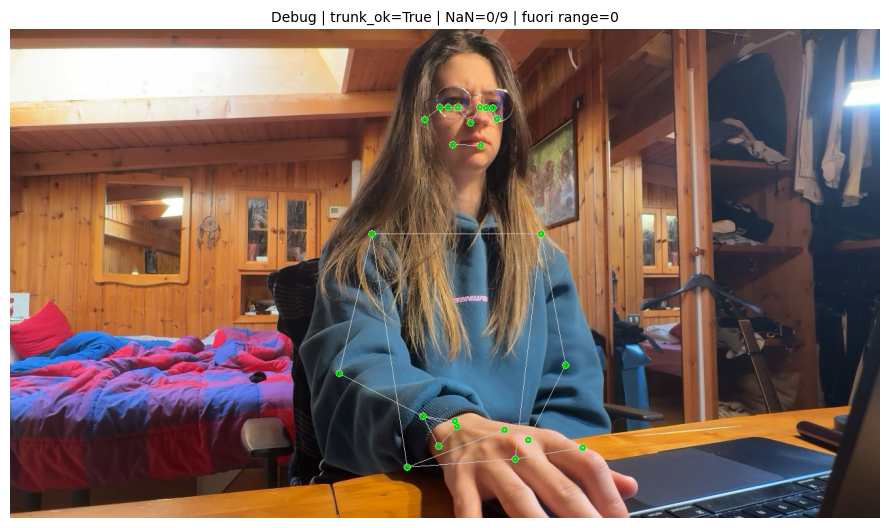


Debug completato.


In [222]:
# Range attesi in postura neutra — inquadratura 30/45°
EXPECTED_RANGES = {
    "head_tilt":                    (-20,  20),
    "shoulder_slope":               (-10,  10),
    "head_lateral_ratio":           (-0.5,  0.2),
    "head_y_ratio":                 (1.0,   2.0),
    "head_neck_vertical_angle":     (0,     25),
    "head_shoulder_alignment":      (-20,   20),
    "upper_body_inclination":       (-20,    5),
    "head_trunk_diff":              (-30,   30),
    "trunk_forward_backward_angle": (-20,   20),
}
 
print("Cattura frame...")
ret, dbg_frame = cap.read()
if not ret:
    raise RuntimeError("cap.read() fallito.")
 
dbg_results = pose.process(cv2.cvtColor(dbg_frame, cv2.COLOR_BGR2RGB))
if not dbg_results.pose_landmarks:
    raise RuntimeError("Nessun landmark rilevato.")
 
dbg_lm        = dbg_results.pose_landmarks.landmark
dbg_lm_array  = landmarks_to_array(dbg_results)
dbg_lm_smooth = smooth_z(dbg_lm_array)
dbg_feat, dbg_ctrl = extract_features_from_array(dbg_lm_smooth, dbg_results)
 
# §1 Visibility
LANDMARK_MAP = {0:"nose", 2:"l_eye", 5:"r_eye", 7:"l_ear", 8:"r_ear",
                11:"l_shoulder", 12:"r_shoulder", 23:"l_hip", 24:"r_hip"}
print("\n" + "═"*60)
print("§1  VISIBILITY")
print("═"*60)
all_vis = {}
for idx, name in LANDMARK_MAP.items():
    v = dbg_lm[idx].visibility
    all_vis[name] = v
    print(f"  {name:<15} {v:.3f}  {'✓' if v >= 0.5 else '✗ ← BASSA'}")
hips_ok = all_vis["l_hip"] >= 0.5 and all_vis["r_hip"] >= 0.5
print(f"\n  → Anche visibili? {'SÌ' if hips_ok else 'NO → trunk_fba = NaN'}")
 
# §2 Reliability
print("\n" + "═"*60)
print("§2  RELIABILITY FLAGS")
print("═"*60)
for k, v in dbg_ctrl.items():
    print(f"  {k:<30} {v}")
trunk_ok = dbg_ctrl.get("trunk_support_reliable", False)
if not trunk_ok:
    print("\n  → trunk_fba = NaN, modello usa imputer (mediana training).")
 
# §3 Feature vs range
print("\n" + "═"*60)
print("§3  FEATURE vs RANGE ATTESO")
print("═"*60)
print(f"  {'feature':<40} {'valore':>9}  {'range':>20}  ok?")
print("  " + "─"*78)
n_nan, n_out = 0, 0
nan_feat, out_feat = [], []
for name in FEATURE_NAMES:
    val   = dbg_feat.get(name, np.nan)
    lo, hi = EXPECTED_RANGES.get(name, (None, None))
    rstr  = f"[{lo}, {hi}]" if lo is not None else "[—]"
    if not np.isfinite(val):
        n_nan += 1; nan_feat.append(name)
        print(f"  {name:<40} {'NaN':>9}  {rstr:>20}  —")
        continue
    ok = (lo is None) or (lo <= val <= hi)
    if not ok:
        n_out += 1; out_feat.append((name, val, lo, hi))
    print(f"  {name:<40} {val:>9.4f}  {rstr:>20}  {'✓' if ok else '⚠'}")
 
# §4 Riepilogo
print("\n" + "═"*60)
print("§4  RIEPILOGO")
print("═"*60)
print(f"\n  NaN ({n_nan}/{len(FEATURE_NAMES)}):")
if nan_feat:
    for f in nan_feat:
        tag = " [support]" if f == "trunk_forward_backward_angle" else " [PRIMARY ← problema]"
        print(f"    · {f}{tag}")
else:
    print("    Nessuna ✓")
print(f"\n  Fuori range ({n_out}):")
if out_feat:
    for fname, fval, lo, hi in out_feat:
        print(f"    · {fname} = {fval:.4f}  (atteso [{lo}, {hi}])")
else:
    print("    Tutte nei range ✓")
 
# §5 Allineamento
print("\n" + "═"*60)
print("§5  ALLINEAMENTO FEATURE_NAMES / BEST_FEATURE_COLUMNS")
print("═"*60)
if set(FEATURE_NAMES) == set(BEST_FEATURE_COLUMNS):
    print(f"  ✓ Allineati — {len(FEATURE_NAMES)} feature.")
else:
    print("  ⚠ NON coincidono — ricaricare i .pkl.")
 
# §6 Frame
dbg_disp = dbg_frame.copy()
mp_drawing.draw_landmarks(dbg_disp, dbg_results.pose_landmarks, mp_pose.POSE_CONNECTIONS,
    landmark_drawing_spec=mp_drawing.DrawingSpec(color=(0,220,0), thickness=2, circle_radius=3),
    connection_drawing_spec=mp_drawing.DrawingSpec(color=(200,200,200), thickness=1))
plt.figure(figsize=(9, 6))
plt.imshow(cv2.cvtColor(dbg_disp, cv2.COLOR_BGR2RGB))
plt.title(f"Debug | trunk_ok={trunk_ok} | NaN={n_nan}/{len(FEATURE_NAMES)} | fuori range={n_out}",
          fontsize=10)
plt.axis("off"); plt.tight_layout(); plt.show()
print("\nDebug completato.")

## Cattura del frame e inferenza completa

FASE 1: CALIBRAZIONE
Siediti in postura corretta e tieni la posizione.
  Inizio tra 5...
  Inizio tra 4...
  Inizio tra 3...
  Inizio tra 2...
  Inizio tra 1...

=== CALIBRAZIONE ===


/opt/homebrew/lib/python3.10/site-packages/google/protobuf/symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


  Frame valido 1/30
  Frame valido 2/30
  Frame valido 3/30
  Frame valido 4/30
  Frame valido 5/30
  Frame valido 6/30
  Frame valido 7/30
  Frame valido 8/30
  Frame valido 9/30
  Frame valido 10/30
  Frame valido 11/30
  Frame valido 12/30
  Frame valido 13/30
  Frame valido 14/30
  Frame valido 15/30
  Frame valido 16/30
  Frame valido 17/30
  Frame valido 18/30
  Frame valido 19/30
  Frame valido 20/30
  Frame valido 21/30
  Frame valido 22/30
  Frame valido 23/30
  Frame valido 24/30
  Frame valido 25/30
  Frame valido 26/30
  Frame valido 27/30
  Frame valido 28/30
  Frame valido 29/30
  Frame valido 30/30

--- Baseline (mediana ± std) ---
  head_tilt                                2.1796  ±3.1121
  shoulder_slope                           -4.6461  ±2.1423
  head_lateral_ratio                       -0.1390  ±0.0444
  head_y_ratio                             1.3493  ±0.0401
  head_neck_vertical_angle                 1.8219  ±0.8495
  head_shoulder_alignment                  4.738

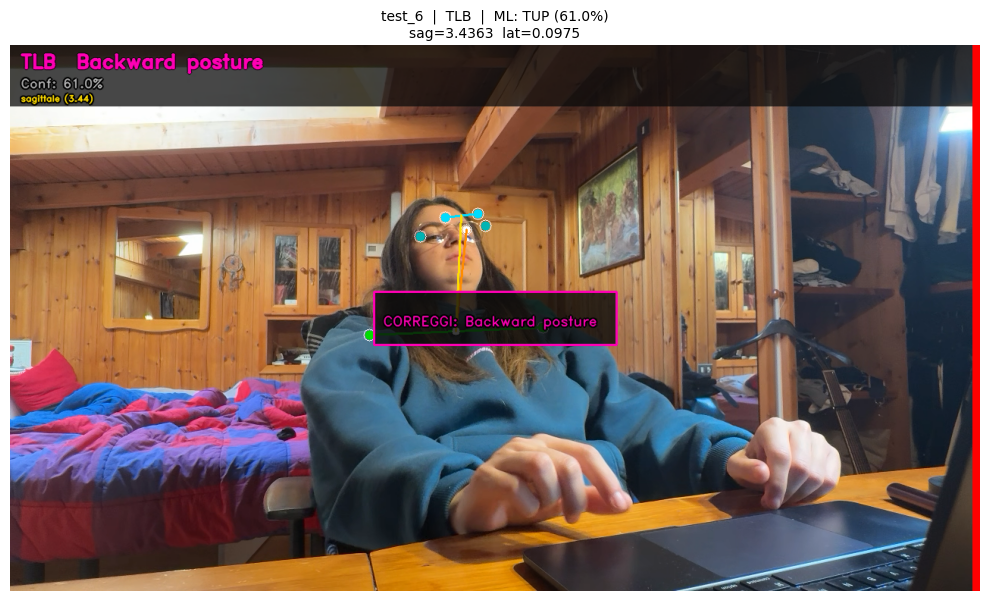


✓ Test 6 salvato in: Test/test_6/
✓ Session log aggiornato.

REPORT SESSIONE
  TLB  Backward posture               100.0%  (1/1)


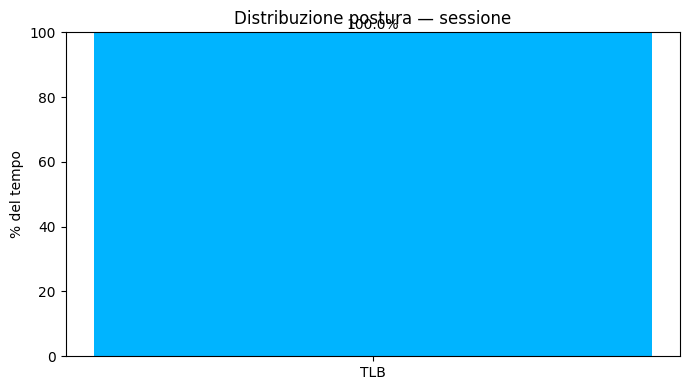

In [229]:
z_buffer.clear()
log_data       = []
baseline_stats = None
TEST_DIR       = "Test"
os.makedirs(TEST_DIR, exist_ok=True)


def _next_test_index(folder):
    indices = []
    for d in os.listdir(folder):
        if d.startswith("test_") and os.path.isdir(os.path.join(folder, d)):
            try:
                indices.append(int(d.replace("test_", "")))
            except ValueError:
                pass
    return max(indices, default=0) + 1


def collect_frames(n_frames, label="Acquisizione"):
    MIN_VALID    = max(8, n_frames // 2)
    collected    = []
    sample_frame = sample_lm = sample_ctrl = None
    print(f"\n=== {label} ===")
    for frame in capture_frames_batch(n_frames * 2):
        if len(collected) >= n_frames:
            break
        try:
            results = pose.process(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        except Exception as e:
            print(f"  Frame scartato: {e}")
            continue
        if not results.pose_landmarks or not check_visibility(results):
            continue
        lm_arr  = smooth_z(landmarks_to_array(results))
        fd, cd  = extract_features_from_array(lm_arr, results)
        mv      = feature_dict_to_model_vector(fd, BEST_FEATURE_COLUMNS)
        if np.all(~np.isfinite(mv)):
            continue
        collected.append((fd, cd, mv))
        if sample_frame is None:
            sample_frame = frame.copy()
            sample_lm    = results.pose_landmarks.landmark
            sample_ctrl  = cd
        print(f"  Frame valido {len(collected)}/{n_frames}")
    if len(collected) < MIN_VALID:
        print(f"  Troppo pochi frame validi ({len(collected)})")
        return None, None, None, None
    return collected, sample_frame, sample_lm, sample_ctrl


def build_baseline_stats(feature_dict_list):
    baseline = {}
    for name in FEATURE_NAMES:
        vals  = np.array([d.get(name, np.nan) for d in feature_dict_list], dtype=float)
        valid = vals[np.isfinite(vals)]
        if len(valid) == 0:
            baseline[name] = {"median": np.nan, "mean": np.nan, "std": np.nan}
        else:
            baseline[name] = {
                "median": float(np.median(valid)),
                "mean":   float(np.mean(valid)),
                "std":    float(np.std(valid)),
            }
    return baseline

def save_test_record(test_idx, baseline_stats, feat_agg, ctrl,
                     vis_dict, label_ml, confidence, probs,
                     label_final, rule_info, feat_print, prob_dict,
                     frame, lm):
    folder = os.path.join(TEST_DIR, f"test_{test_idx}")
    os.makedirs(folder, exist_ok=True)

    baseline_serial = {
        name: {k: (float(v) if np.isfinite(v) else None) for k, v in stats.items()}
        for name, stats in baseline_stats.items()
    }
    record = {
        "test_index":       test_idx,
        "timestamp":        datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        "baseline":         baseline_serial,
        "features":         feat_print,
        "control_flags":    {k: str(v) for k, v in (ctrl or {}).items()},
        "visibility":       vis_dict,
        "lateral_score":    rule_info["lateral_score"],
        "sagittal_score":   rule_info["sagittal_score"],
        "rule_triggered":   rule_info["rule_triggered"],
        "rule_reason":      rule_info["reason"],
        "confidence_tier":  rule_info["confidence_tier"],
        "probabilities":    prob_dict,
        "prediction_ml":    label_ml,
        "confidence_ml":    round(confidence, 4),
        "prediction_final": label_final,
    }
    with open(os.path.join(folder, "data.json"), "w") as f:
        json.dump(record, f, indent=2)

    if frame is not None and lm is not None:
        frame_out = draw_debug_overlay(frame.copy(), lm, feat_agg,
                                       label_final, confidence,
                                       rule_info["confidence_tier"], rule_info)
        fig, ax = plt.subplots(figsize=(10, 7))
        ax.imshow(cv2.cvtColor(frame_out, cv2.COLOR_BGR2RGB))
        ax.set_title(
            f"test_{test_idx}  |  {label_final}  |  ML: {label_ml} ({confidence:.1%})\n"
            f"sag={rule_info['sagittal_score']}  lat={rule_info['lateral_score']}",
            fontsize=10)
        ax.axis("off")
        plt.tight_layout()
        plt.savefig(os.path.join(folder, "frame.png"), dpi=150)
        plt.show()
    return folder


def show_report(log_data):
    if not log_data:
        print("Nessun dato nel log.")
        return
    totale   = len(log_data)
    conteggi = {}
    for e in log_data:
        l = e["prediction_final"]
        conteggi[l] = conteggi.get(l, 0) + 1
    print("\n" + "="*50)
    print("REPORT SESSIONE")
    print("="*50)
    for l, cnt in sorted(conteggi.items()):
        print(f"  {l}  {LABEL_DESC.get(l, l):<30} {cnt/totale*100:5.1f}%  ({cnt}/{totale})")
    labels = list(conteggi.keys())
    valori = [conteggi[l] / totale * 100 for l in labels]
    colori = [(0/255,220/255,0/255) if l=="TUP" else
              (255/255,100/255,0/255) if l in ("TLL","TLR") else
              (0/255,180/255,255/255) for l in labels]
    plt.figure(figsize=(7, 4))
    plt.bar(labels, valori, color=colori)
    plt.ylabel("% del tempo"); plt.title("Distribuzione postura — sessione")
    plt.ylim(0, 100)
    for i, v in enumerate(valori):
        plt.text(i, v+1, f"{v:.1f}%", ha="center", fontsize=10)
    plt.tight_layout()
    plt.savefig("report_sessione.png", dpi=150)
    plt.show()


# ════════════════════════
# FASE 1: CALIBRAZIONE
# ════════════════════════
print("="*60)
print("FASE 1: CALIBRAZIONE")
print("Siediti in postura corretta e tieni la posizione.")
print("="*60)
for s in range(5, 0, -1):
    print(f"  Inizio tra {s}...")
    time.sleep(1)

calib_data, _, _, _ = collect_frames(CALIBRATION_FRAMES, "CALIBRAZIONE")
if calib_data is None:
    print("Calibrazione fallita. Rilanciare la cella.")
else:
    baseline_stats = build_baseline_stats([x[0] for x in calib_data])
    print("\n--- Baseline (mediana ± std) ---")
    for name in FEATURE_NAMES:
        m = baseline_stats[name]["median"]
        s = baseline_stats[name]["std"]
        ms = f"{m:.4f}" if np.isfinite(m) else "NaN"
        ss = f"{s:.4f}" if np.isfinite(s) else "NaN"
        print(f"  {name:<40} {ms}  ±{ss}")


# ════════════════════════
# FASE 2: CLASSIFICAZIONE
# ════════════════════════
print("\n" + "="*60)
print("FASE 2: CLASSIFICAZIONE")
print("Assumi la postura da classificare.")
print("="*60)
for s in range(5, 0, -1):
    print(f"  Acquisizione tra {s}...")
    time.sleep(1)

post_data, sample_frame, sample_lm, sample_ctrl = collect_frames(
    POSTURE_FRAMES, "ACQUISIZIONE POSTURA"
)

if post_data is None:
    print("Acquisizione fallita. Rilanciare la cella.")
else:
    post_fds  = [x[0] for x in post_data]
    post_mvs  = np.array([x[2] for x in post_data], dtype=float)
    feat_agg_model = np.nanmedian(post_mvs, axis=0)

    # Mediana feature per regole e debug
    feat_agg = {}
    for name in FEATURE_NAMES:
        vals = np.array([d.get(name, np.nan) for d in post_fds], dtype=float)
        feat_agg[name] = float(np.nanmedian(vals)) if np.isfinite(vals).any() else np.nan

    # Feature print
    print("\n=== FEATURE AGGREGATE ===")
    feat_print = {}
    for name in FEATURE_NAMES:
        val = feat_agg.get(name, np.nan)
        if np.isfinite(val):
            print(f"  {name:<40} {val:.4f}")
            feat_print[name] = round(float(val), 4)
        else:
            print(f"  {name:<40} NaN")
            feat_print[name] = None

    # Visibility
    print("\n=== VISIBILITY ===")
    vis_dict = {}
    if sample_lm is not None:
        for idx, name in [(0,"nose"),(2,"l_eye"),(5,"r_eye"),(7,"l_ear"),(8,"r_ear"),
                          (11,"l_shoulder"),(12,"r_shoulder"),(23,"l_hip"),(24,"r_hip")]:
            v = sample_lm[idx].visibility
            vis_dict[name] = round(float(v), 3)
            print(f"  {name:<15} {v:.3f}")

    # Predizione ML
    label_ml, confidence, probs = predict(feat_agg_model, best_model, label_encoder)

    # Classificazione finale
    label_final, rule_info = classify_posture(
        label_ml, confidence, feat_agg, baseline_stats
    )

    # Output probabilità
    print("\n=== PROBABILITÀ PER CLASSE ===")
    prob_dict = {}
    for cls, prob in zip(label_encoder.classes_, probs):
        bar  = "█" * int(prob * 30)
        mark = " ◄ ML" if cls == label_ml else ""
        print(f"  {cls}  {prob:.4f}  {bar}{mark}")
        prob_dict[cls] = round(float(prob), 4)

    print(f"\n→ ML:      {label_ml}  ({confidence:.2%})")
    print(f"→ Finale:  {label_final}")
    print(f"→ Tier:    {rule_info['confidence_tier']}")
    print(f"→ Regola:  {rule_info['reason']}")
    print(f"→ Lat:     {rule_info['lateral_score']}  |  Sag: {rule_info['sagittal_score']}")

    # Salvataggio
    test_idx    = _next_test_index(TEST_DIR)
    test_folder = save_test_record(
        test_idx, baseline_stats, feat_agg, sample_ctrl,
        vis_dict, label_ml, confidence, probs,
        label_final, rule_info, feat_print, prob_dict,
        sample_frame, sample_lm
    )
    print(f"\n✓ Test {test_idx} salvato in: {test_folder}/")

    # Log sessione
    log_data.append({
        "timestamp":        datetime.now().strftime("%H:%M:%S"),
        "test_index":       test_idx,
        "prediction_ml":    label_ml,
        "prediction_final": label_final,
        "confidence":       round(confidence, 4),
        "confidence_tier":  rule_info["confidence_tier"],
        "rule_triggered":   rule_info["rule_triggered"],
        "rule_reason":      rule_info["reason"],
        "lateral_score":    rule_info["lateral_score"],
        "sagittal_score":   rule_info["sagittal_score"],
        "features":         feat_print,
        "visibility":       vis_dict,
        "probabilities":    prob_dict,
    })
    with open(os.path.join(TEST_DIR, "session_log.json"), "w") as f:
        json.dump(log_data, f, indent=2)
    print(f"✓ Session log aggiornato.")

    show_report(log_data)

## Chiusura connessione

In [230]:
cap.release()
cv2.destroyAllWindows()
print("Connessione chiusa.")

Connessione chiusa.
